In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import math

In [5]:
df = pd.read_csv('debug_distribution.csv')
df

,step,from_idx,to_idx,raw_drive,raw_turn,walk,exit_drive,exit_turn,cross,p_i,...,norm_cross,norm_exit_turn,fail_prob,drive_weight,lambda_w,lambda_e,lambda_tr,lambda_turns_arr,lambda_turns_exit,lambda_cross
0,0,-1,0,256.429852,154.0,64.768451,271.593839,80.0,0.0,0.5,...,0.000000,0.0,1.00,1.0,4.0,1.0,3.0,0.0,0.0,25.0
1,0,-1,1,256.429979,154.0,89.006355,271.593695,80.0,0.0,0.5,...,0.000000,0.0,1.00,1.0,4.0,1.0,3.0,0.0,0.0,25.0
2,0,-1,2,140.806216,14.0,91.816479,215.705936,64.0,15.0,0.5,...,8.333333,0.0,1.00,1.0,4.0,1.0,3.0,0.0,0.0,25.0
3,0,-1,3,344.549454,210.0,94.521167,285.614567,144.0,0.0,0.5,...,0.000000,0.0,1.00,1.0,4.0,1.0,3.0,0.0,0.0,25.0
4,0,-1,4,140.806149,14.0,124.355566,215.706014,64.0,15.0,0.5,...,8.333333,0.0,1.00,1.0,4.0,1.0,3.0,0.0,0.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7573,2,27,24,268.597902,91.0,307.828346,314.979220,176.0,45.0,0.5,...,25.000000,0.0,0.25,3.0,4.0,1.0,3.0,0.0,0.0,25.0
7574,2,27,25,325.224134,56.0,320.534095,250.076971,80.0,15.0,0.5,...,8.333333,0.0,0.25,3.0,4.0,1.0,3.0,0.0,0.0,25.0
7575,2,27,26,62.608583,0.0,329.238588,394.639099,160.0,15.0,0.5,...,8.333333,0.0,0.25,3.0,4.0,1.0,3.0,0.0,0.0,25.0
7576,2,27,28,343.896627,98.0,336.151943,323.534292,96.0,30.0,0.5,...,16.666667,0.0,0.25,3.0,4.0,1.0,3.0,0.0,0.0,25.0


In [7]:
df.columns

Index(['step', 'from_idx', 'to_idx', 'raw_drive', 'raw_turn', 'walk',
       'exit_drive', 'exit_turn', 'cross', 'p_i', 'pure_norm_drive',
       'pure_norm_turn', 'pure_norm_walk', 'pure_norm_exit', 'pure_norm_cross',
       'pure_norm_exit_turn', 'norm_drive', 'norm_turn', 'norm_walk',
       'norm_exit', 'norm_cross', 'norm_exit_turn', 'fail_prob',
       'drive_weight', 'lambda_w', 'lambda_e', 'lambda_tr', 'lambda_turns_arr',
       'lambda_turns_exit', 'lambda_cross'],
      dtype='str')

In [10]:
df.describe()

,pure_norm_drive,pure_norm_turn,pure_norm_walk,pure_norm_exit,pure_norm_cross,pure_norm_exit_turn,norm_drive,norm_turn,norm_walk,norm_exit,norm_cross,norm_exit_turn,fail_prob
count,7.578000e+03,7578.000000,7578.000000,7578.000000,7578.000000,7578.000000,7.578000e+03,7578.0,7578.000000,7578.000000,7578.000000,7578.0,7578.000000
mean,4.497210e-01,0.389604,0.593401,0.686256,0.395663,0.487284,1.347791e+00,0.0,2.373604,0.686256,9.891572,0.0,0.259501
std,2.205212e-01,0.274388,0.216374,0.156017,0.287231,0.180464,6.617322e-01,0.0,0.865497,0.156017,7.180776,0.0,0.052257
min,4.148733e-08,0.000000,0.171940,0.401869,0.000000,0.190476,1.244620e-07,0.0,0.687760,0.401869,0.000000,0.0,0.250000
25%,2.867522e-01,0.166667,0.456987,0.574452,0.333333,0.317460,8.578353e-01,0.0,1.827950,0.574452,8.333333,0.0,0.250000
50%,4.553105e-01,0.388889,0.599831,0.654822,0.333333,0.444444,1.365931e+00,0.0,2.399323,0.654822,8.333333,0.0,0.250000
75%,6.004276e-01,0.583333,0.744213,0.768736,0.666667,0.634921,1.801283e+00,0.0,2.976852,0.768736,16.666667,0.0,0.250000
max,1.176630e+00,1.388889,1.000000,1.000000,1.000000,0.888889,3.529891e+00,0.0,4.000000,1.000000,25.000000,0.0,1.000000


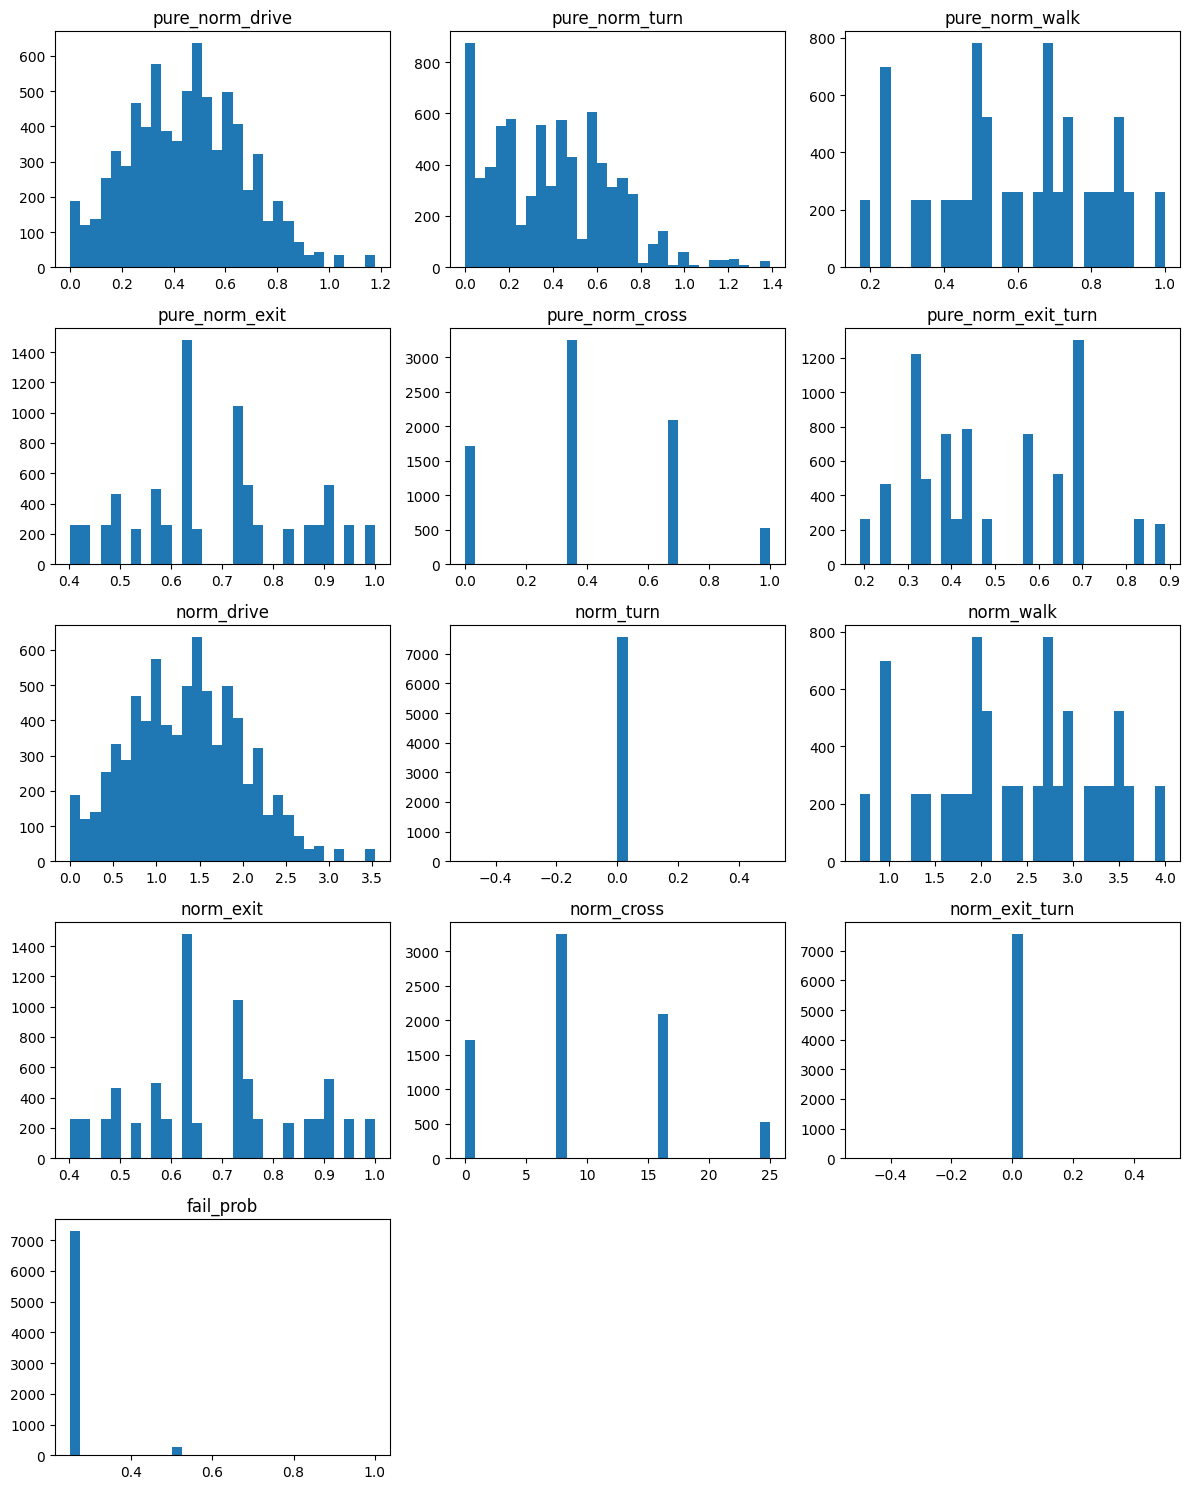

In [8]:
cols = [
    'pure_norm_drive',
       'pure_norm_turn', 'pure_norm_walk', 'pure_norm_exit', 'pure_norm_cross',
       'pure_norm_exit_turn', 'norm_drive', 'norm_turn', 'norm_walk',
       'norm_exit', 'norm_cross', 'norm_exit_turn', 'fail_prob'
]

df = df[cols].dropna()

n = len(cols)
rows = math.ceil(n / 3)

plt.figure(figsize=(12, rows * 3))

for i, col in enumerate(cols):
    plt.subplot(rows, 3, i + 1)
    plt.hist(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

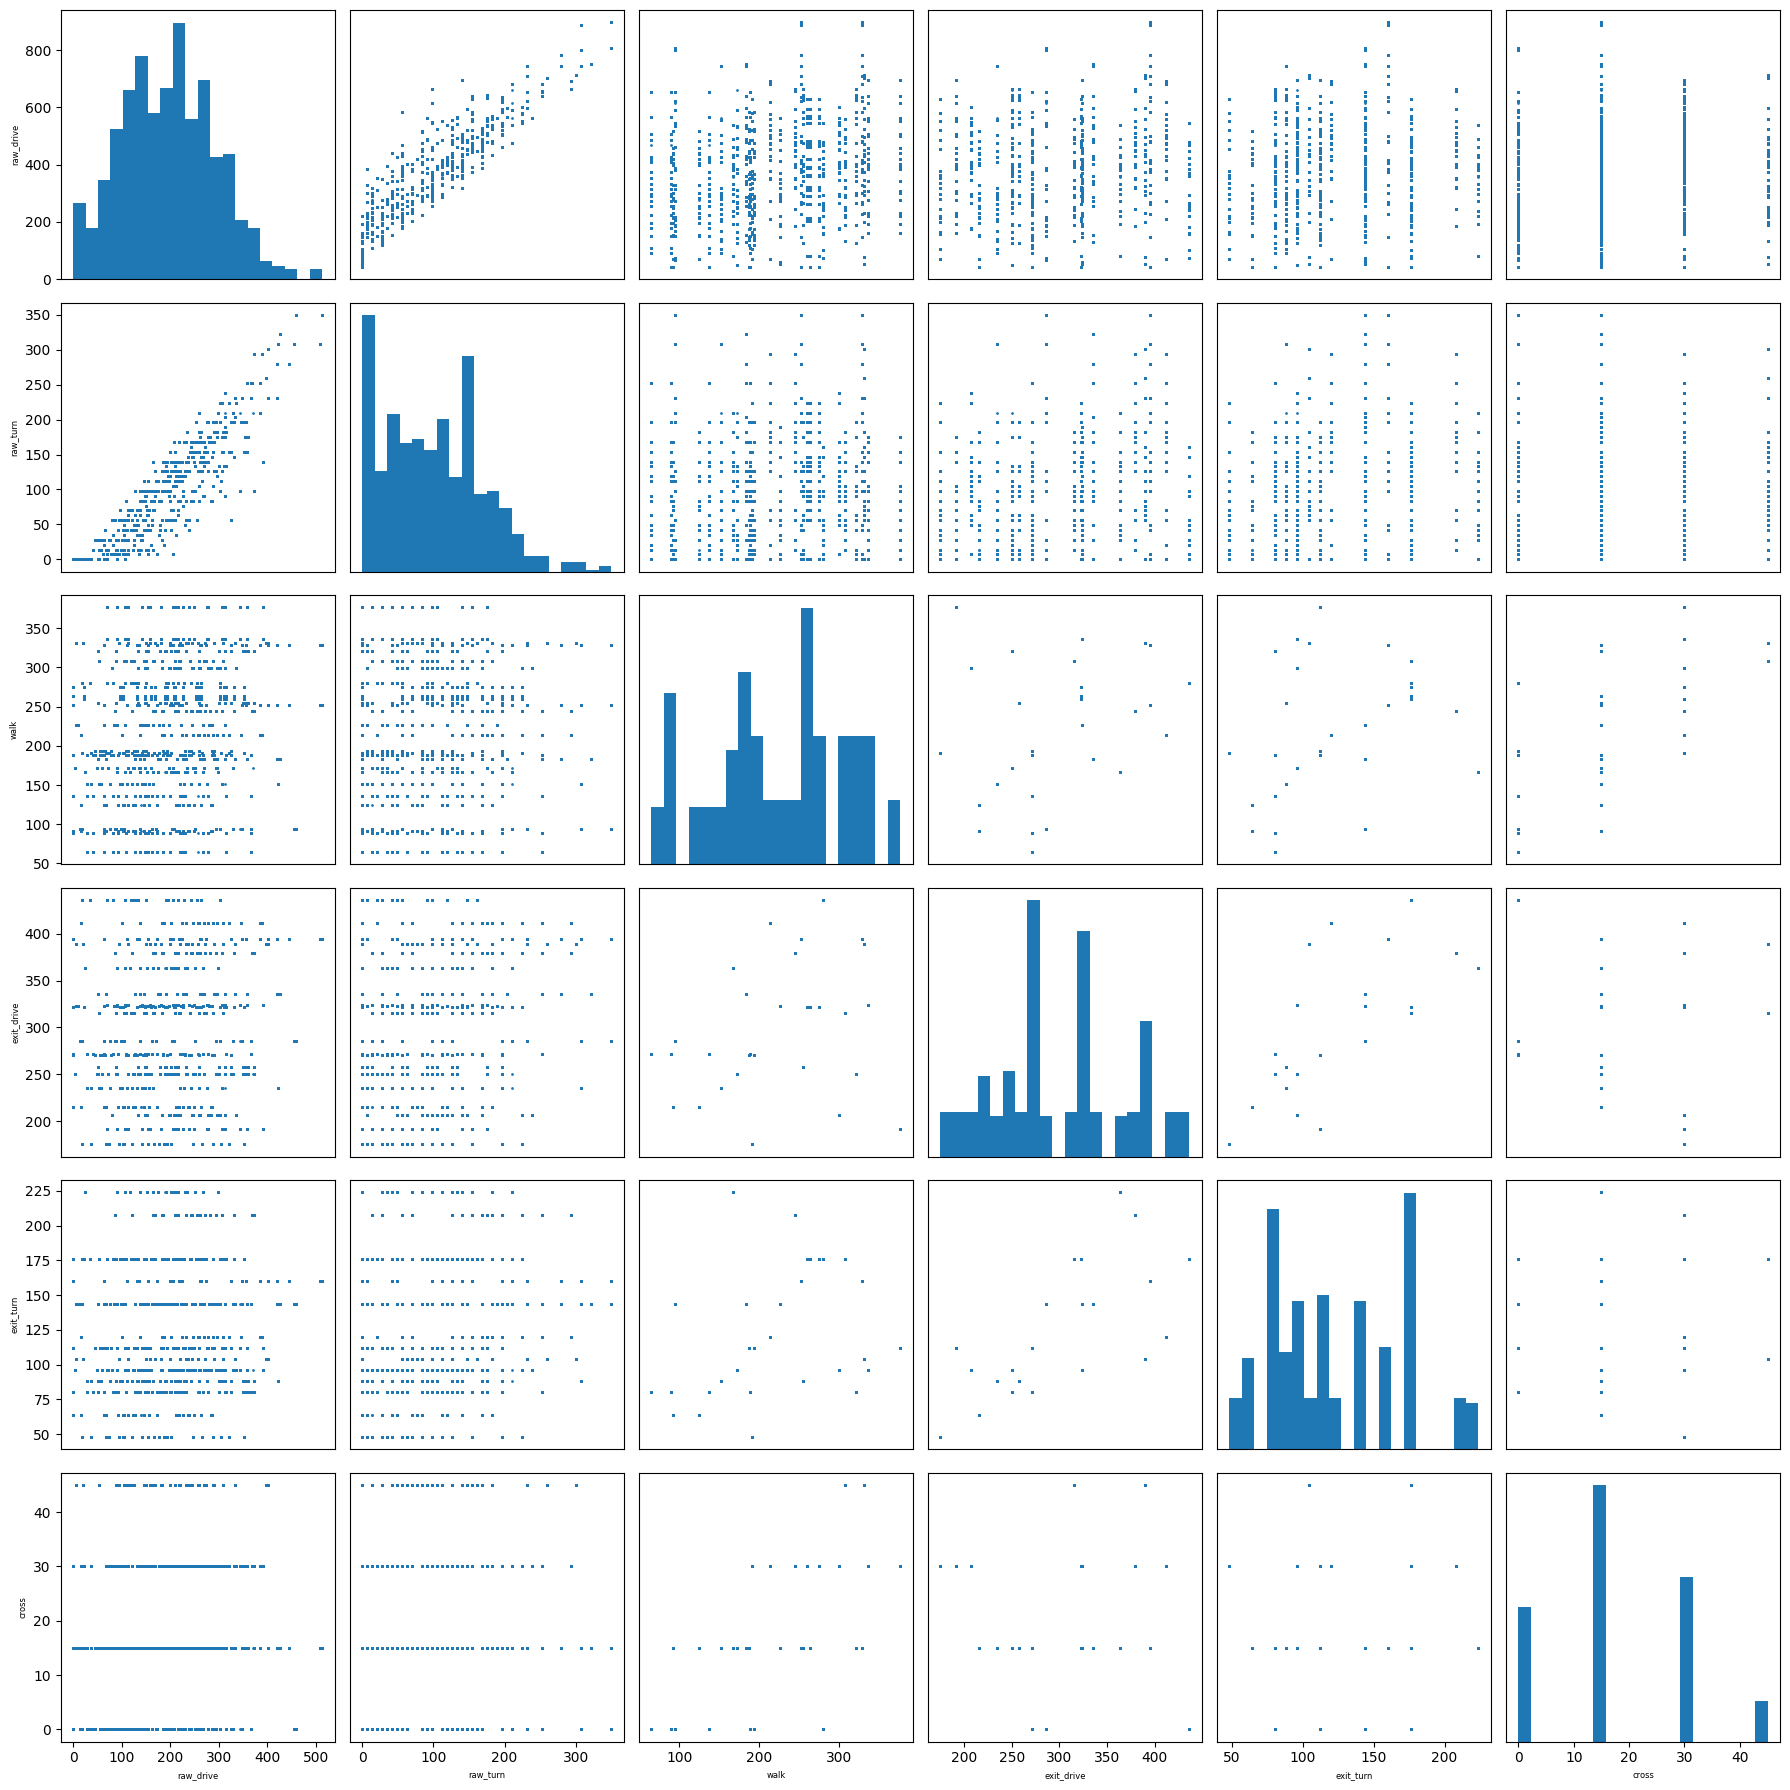

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("debug_distribution.csv")

cols = [
    "raw_drive","raw_turn","walk","exit_drive","exit_turn",
    "cross"
]

df = df[cols].dropna()

n = len(cols)

fig, axes = plt.subplots(n, n, figsize=(18, 18))

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i == j:
            ax.hist(df[cols[i]], bins=20)
        else:
            ax.scatter(df[cols[j]], df[cols[i]], s=1)

        if i == n - 1:
            ax.set_xlabel(cols[j], fontsize=6)
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(cols[i], fontsize=6)
        else:
            ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
"norm_drive","norm_turn","norm_walk",
    "norm_exit","norm_cross","norm_exit_turn","fail_prob","drive_weight"

In [2]:
df

,raw_drive,raw_turn,walk,exit_drive,exit_turn,cross,p_i,norm_drive,norm_turn,norm_walk,norm_exit,norm_cross,norm_exit_turn,fail_prob,drive_weight
0,256.429852,154.0,64.768451,271.593839,80.0,0.0,0.5,0.587911,0.0,0.687760,0.622677,0.000000,0.0,1.00,1.0
1,256.429979,154.0,89.006355,271.593695,80.0,0.0,0.5,0.587912,0.0,0.945136,0.622677,0.000000,0.0,1.00,1.0
2,140.806216,14.0,91.816479,215.705936,64.0,15.0,0.5,0.322823,0.0,0.974976,0.494544,8.333333,0.0,1.00,1.0
3,344.549454,210.0,94.521167,285.614567,144.0,0.0,0.5,0.789941,0.0,1.003696,0.654822,0.000000,0.0,1.00,1.0
4,140.806149,14.0,124.355566,215.706014,64.0,15.0,0.5,0.322823,0.0,1.320500,0.494545,8.333333,0.0,1.00,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7573,268.597902,91.0,307.828346,314.979220,176.0,45.0,0.5,1.847426,0.0,3.268751,0.722146,25.000000,0.0,0.25,3.0
7574,325.224134,56.0,320.534095,250.076971,80.0,15.0,0.5,2.236903,0.0,3.403670,0.573346,8.333333,0.0,0.25,3.0
7575,62.608583,0.0,329.238588,394.639099,160.0,15.0,0.5,0.430624,0.0,3.496101,0.904781,8.333333,0.0,0.25,3.0
7576,343.896627,98.0,336.151943,323.534292,96.0,30.0,0.5,2.365333,0.0,3.569512,0.741760,16.666667,0.0,0.25,3.0


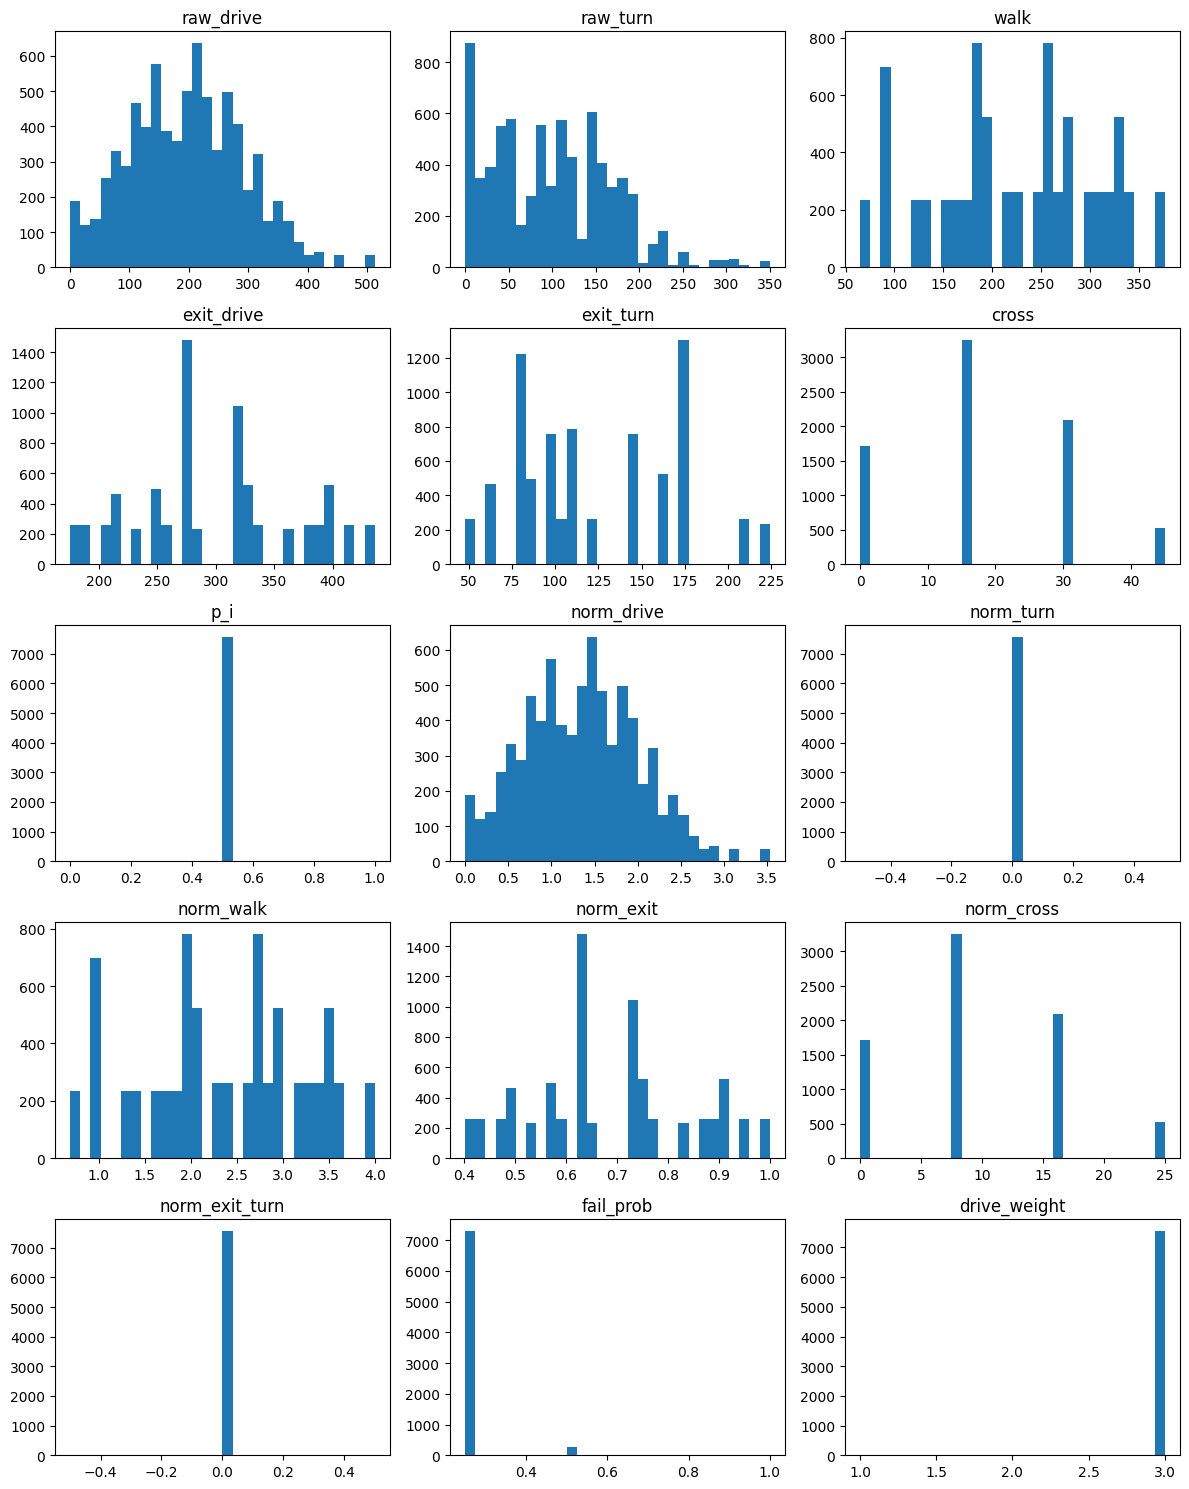

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math


df = pd.read_csv("debug_distribution.csv")

cols = [
    "raw_drive","raw_turn","walk","exit_drive","exit_turn",
    "cross","p_i","norm_drive","norm_turn","norm_walk",
    "norm_exit","norm_cross","norm_exit_turn","fail_prob","drive_weight"
]

df = df[cols].dropna()

n = len(cols)
rows = math.ceil(n / 3)

plt.figure(figsize=(12, rows * 3))

for i, col in enumerate(cols):
    plt.subplot(rows, 3, i + 1)
    plt.hist(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

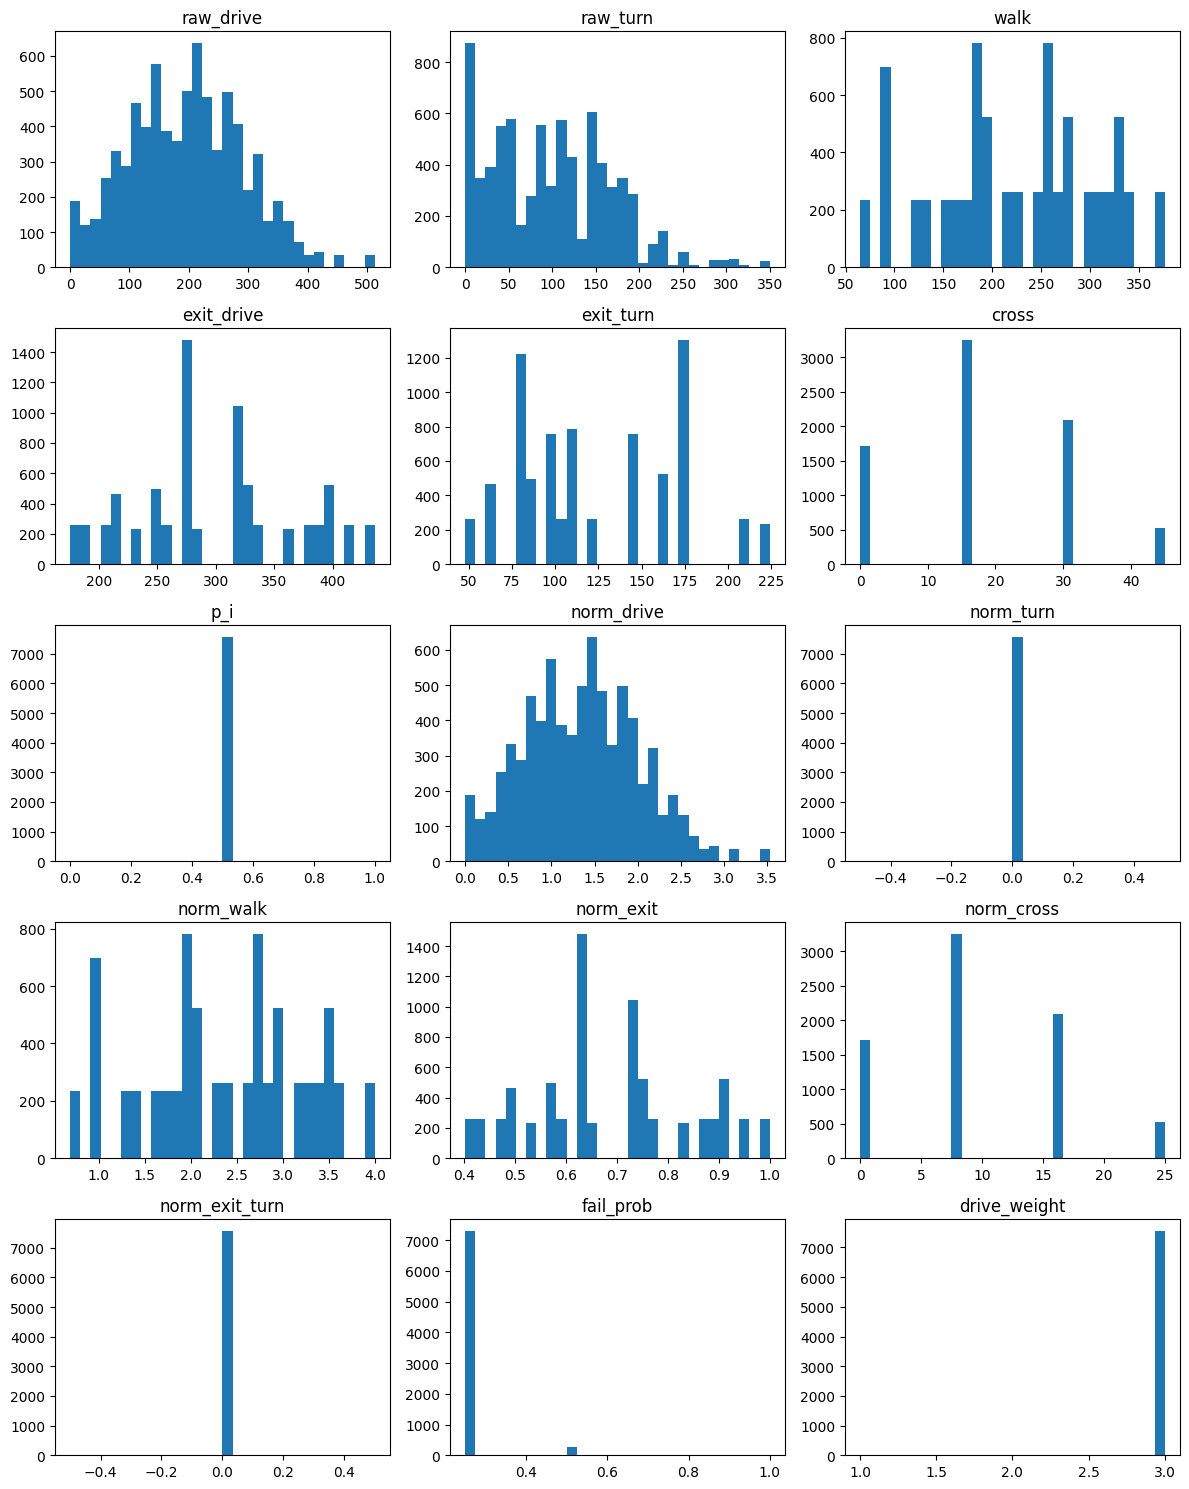

In [3]:
cols = [
    "raw_drive","raw_turn","walk","exit_drive","exit_turn",
    "cross","p_i","norm_drive","norm_turn","norm_walk",
    "norm_exit","norm_cross","norm_exit_turn","fail_prob","drive_weight"
]

df = df[cols].dropna()

n = len(cols)
rows = math.ceil(n / 3)

plt.figure(figsize=(12, rows * 3))

for i, col in enumerate(cols):
    plt.subplot(rows, 3, i + 1)
    plt.hist(df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [2]:
from ipyleaflet import Map, Marker
from IPython.display import display

m = Map(center=(51.1694, 71.4491), zoom=12)
current_marker = None

def handle_click(**kwargs):
    global current_marker
    if kwargs.get("type") == "click":
        lat, lng = kwargs.get("coordinates")
        print("Clicked:", [lat, lng])

        if current_marker is not None:
            m.remove_layer(current_marker)

        current_marker = Marker(location=(lat, lng))
        m.add_layer(current_marker)

m.on_interaction(handle_click)
display(m)

Map(center=[51.1694, 71.4491], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zo…

In [3]:
from IPython.display import clear_output, display

def handle_click(**kwargs):
    global current_marker
    if kwargs.get("type") == "click":
        lat, lng = kwargs.get("coordinates")

        # force output refresh
        clear_output(wait=True)
        display(m)

        print(f"Clicked: [{lat:.6f}, {lng:.6f}]")

        if current_marker is not None:
            m.remove_layer(current_marker)

        current_marker = Marker(location=(lat, lng))
        m.add_layer(current_marker)

In [4]:
m.on_interaction(handle_click)
display(m)

Map(bottom=2803644.0, center=[51.13143080981383, 71.38435363769533], controls=(ZoomControl(options=['position'…

In [ ]:
from ipyleaflet import Map, Marker
from ipywidgets import Output, VBox
from IPython.display import display

m = Map(center=(51.1694, 71.4491), zoom=12)
out = Output()

current_marker = None
last_point = None

def handle_click(**kwargs):
    global current_marker, last_point
    
    if kwargs.get("type") == "click":
        lat, lng = kwargs.get("coordinates")
        last_point = (lat, lng)

        if current_marker is not None:
            m.remove_layer(current_marker)

        current_marker = Marker(location=last_point)
        m.add_layer(current_marker)

        with out:
            out.clear_output()
            print(f"Clicked: [{lat:.8f}, {lng:.8f}]")


m.on_interaction(handle_click)

display(VBox([m, out]))

In [ ]:
[51.132185, 71.372981]

In [ ]:
[51.132225, 71.373003]

In [ ]:
import routing
import networkx as nx
import pandas as pd

routing.initialize_graph()
G = routing.G

print("Base OSM graph")
print("nodes:", G.number_of_nodes())
print("edges:", G.number_of_edges())
print("is directed:", G.is_directed())
print("is multigraph:", G.is_multigraph())

Base OSM graph
nodes: 8494
edges: 21062
is directed: True
is multigraph: True


In [4]:
import os

In [ ]:
# Example:
# MANUAL_SPOTS = [
#     {"id": "s1", "coords": (51.1247, 71.4321), "street": "Spot 1", "p_i": 0.8, "phi_exit_seconds": 60},
#     ...
# ]
def load_json(path, default):
    if os.path.exists(path):
        try:
            with open(path, "r") as f:
                return json.load(f)
        except:
            return default
    return default


def save_json(path, data):
    with open(path, "w") as f:
        json.dump(data, f)
        
MANUAL_FILE = os.path.join("manual_spots_new.json")
MANUAL_SPOTS = load_json(MANUAL_FILE, [])
G_aug = routing.augment_graph_with_spots(MANUAL_SPOTS)

print("Augmented graph")
print("nodes:", G_aug.number_of_nodes())
print("edges:", G_aug.number_of_edges())

print("\nDifference")
print("added nodes:", G_aug.number_of_nodes() - G.number_of_nodes())
print("added edges:", G_aug.number_of_edges() - G.number_of_edges())

manual_nodes = [n for n, d in G_aug.nodes(data=True) if d.get("is_manual", False)]
print("manual spot nodes:", len(manual_nodes))
print("manual node ids sample:", manual_nodes[:10])

Augmented graph
nodes: 8494
edges: 21062

Difference
added nodes: 0
added edges: 0
manual spot nodes: 0
manual node ids sample: []


In [6]:
rows = []

for s in MANUAL_SPOTS:
    rows.append({
        "spot_id": s["id"],
        "coords": s["coords"],
        "_edge": s.get("_edge"),
        "_node_id": s.get("_node_id"),
        "_proj_coords": s.get("_proj_coords"),
        "_bearing": s.get("_bearing"),
    })

df_spots = pd.DataFrame(rows)
df_spots

""


In [ ]:
from twogis_routing import get_route_2gis

start = (51.19034801714996, 71.4070625470186)   # example
dest  = (51.12143227387381, 71.42878515268714)  # example

osm_res = routing.get_route(start, dest, custom_G=G)
twogis_res = get_route_2gis(start, dest)

print("OSM route:")
print("travel_time:", osm_res["travel_time"])
print("turn_penalty:", osm_res["turn_penalty"])
print("num_path_points:", len(osm_res["path"]))
print("num_nodes:", len(osm_res["nodes"]))

print("\n2GIS route:")
if twogis_res:
    print("travel_time:", twogis_res["travel_time"])
    print("turn_penalty:", twogis_res["turn_penalty"])
    print("num_path_points:", len(twogis_res["path"]))
    print("num_nodes:", len(twogis_res["nodes"]))
else:
    print("2GIS failed")

OSM route:
travel_time: 680.0834940053331
turn_penalty: 135.0
num_path_points: 191
num_nodes: 66

2GIS route:
travel_time: 1745.0
turn_penalty: 0.0
num_path_points: 328
num_nodes: 0


In [8]:
comparison = pd.DataFrame([
    {
        "source": "OSM_graph",
        "travel_time_sec": osm_res["travel_time"],
        "turn_penalty_sec": osm_res["turn_penalty"],
        "path_points": len(osm_res["path"]),
        "graph_nodes": len(osm_res["nodes"]),
    },
    {
        "source": "2GIS_api",
        "travel_time_sec": None if twogis_res is None else twogis_res["travel_time"],
        "turn_penalty_sec": None if twogis_res is None else twogis_res["turn_penalty"],
        "path_points": None if twogis_res is None else len(twogis_res["path"]),
        "graph_nodes": None if twogis_res is None else len(twogis_res["nodes"]),
    }
])

comparison

,source,travel_time_sec,turn_penalty_sec,path_points,graph_nodes
0,OSM_graph,680.083494,135.0,191,66
1,2GIS_api,1745.000000,0.0,328,0


In [9]:
import folium

m = folium.Map(location=start, zoom_start=13)

folium.Marker(start, popup="start", icon=folium.Icon(color="green")).add_to(m)
folium.Marker(dest, popup="dest", icon=folium.Icon(color="red")).add_to(m)

if osm_res["path"]:
    folium.PolyLine(
        osm_res["path"],
        color="blue",
        weight=5,
        opacity=0.8,
        tooltip="OSM graph route"
    ).add_to(m)

if twogis_res and twogis_res["path"]:
    folium.PolyLine(
        twogis_res["path"],
        color="orange",
        weight=5,
        opacity=0.8,
        tooltip="2GIS route"
    ).add_to(m)

m

In [ ]:
from locations import LOCATIONS
from twogis_routing import get_route_2gis

rows = []

for name, loc in LOCATIONS.items():
    start = tuple(loc["start"])
    dest = tuple(loc["dest"])

    osm_res = routing.get_route(start, dest, custom_G=G)
    twogis_res = get_route_2gis(start, dest)

    rows.append({
        "set": name,
        "osm_time_sec": osm_res["travel_time"],
        "osm_turn_sec": osm_res["turn_penalty"],
        "osm_nodes": len(osm_res["nodes"]),
        "twogis_time_sec": None if twogis_res is None else twogis_res["travel_time"],
        "twogis_nodes": None if twogis_res is None else len(twogis_res["nodes"]),
        "time_diff_sec": None if twogis_res is None else osm_res["travel_time"] - twogis_res["travel_time"],
    })

df_compare = pd.DataFrame(rows)
df_compare

,set,osm_time_sec,osm_turn_sec,osm_nodes,twogis_time_sec,twogis_nodes,time_diff_sec
0,Set 1: N-N,680.083494,135.0,66,1751.0,0,-1070.916506
1,Set 2: N-E,680.083494,135.0,66,1751.0,0,-1070.916506
2,Set 3: N-S,680.083494,135.0,66,1751.0,0,-1070.916506
3,Set 4: N-W,680.083494,135.0,66,1751.0,0,-1070.916506
4,Set 5: E-E,267.624137,70.0,18,552.0,0,-284.375863
5,Set 6: E-S,267.624137,70.0,18,552.0,0,-284.375863
6,Set 7: E-W,267.624137,70.0,18,552.0,0,-284.375863
7,Set 8: E-N,267.624137,70.0,18,552.0,0,-284.375863
8,Set 9: S-S,424.944255,145.0,27,1054.0,0,-629.055745
9,Set 10: S-W,424.944255,145.0,27,1054.0,0,-629.055745


In [11]:
print("OSM route nodes example:")
print(osm_res["nodes"][:10])

if twogis_res:
    print("\n2GIS route nodes example:")
    print(twogis_res["nodes"])

OSM route nodes example:
[4922159709, 4922159702, 3269921756, 5016102471, 259996115, 2365248304, 1772898840, 1772898847, 2316666036, 5028546996]

2GIS route nodes example:
[]
